In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

In [34]:
### TEST DATA ###
# IR Climate Data
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))-273.15
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast, savefile = None)

era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).sel(time = slice("1996-01-01", "2025-12-31"))-273.15
era5_ir = isku_utils.grid_to_ir(era5, savefile = None)
era5_ir = era5_ir.assign_coords(month=era5_ir["time"].dt.month)
#Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "2608_beta_qdm_gamma_sampled.zarr")).sel(sample = 7)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [72]:
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import cartopy.crs as ccrs
from scipy.interpolate import interp1d
from shapely import box

import diagnostic_utils
importlib.reload(diagnostic_utils)

### Analysis Options ###
rate = True # Mortality Rate vs Total Deaths
hotonly = False # Hot-Only Deaths
age_weight = False #Proportional Age-weighting vs single age group
density_hist = False #Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "MOZ.8.Ra1718841d5afe6a8"

# Compute Impact
projected = effect
regional_sum = analysis_utils.compute_impact(projected, socioeconomics, baseline_period= baseline_period, hotonly = hotonly, rate = rate, age_weight = age_weight)

#Get Months
months = regional_sum.month.values

### Load Climate Data ###
#Select representative ensemble member
forecast_slice = forecast_ir['tas'].sel(number = 1)
forecast_local = forecast_slice.sel(region = region_filter)

#Select representative year
reanalysis_slice = era5_ir['tas'].sel(time=slice('2000-01-01', '2000-12-31'))
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
reanalysis_local = reanalysis_slice.sel(region = region_filter)

combined = np.concat([forecast_local.values.flatten(), reanalysis_local.values.flatten()])
xmin, xmax = np.percentile(combined, [1, 100])

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(forecast_slice, reanalysis_slice, region_filter, months, hotonly = hotonly)

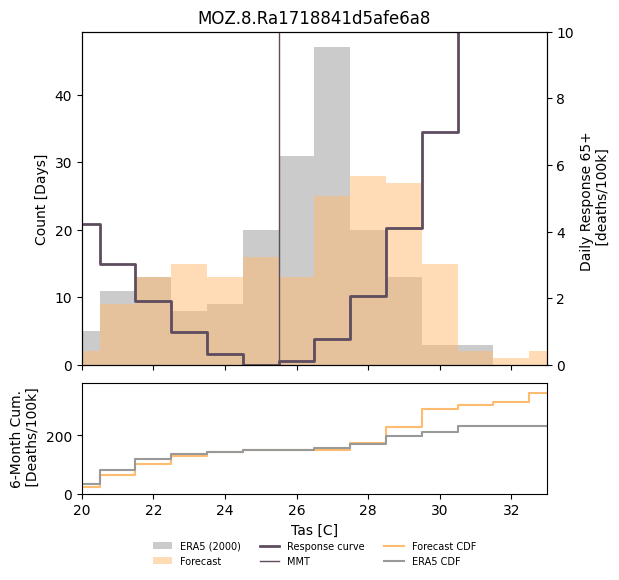

In [74]:
#Histogram

b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

fig, (ax_hist, ax_cdf) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 6),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}
)


ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus')
betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] 

# Density histograms on hidden twin axis
bins = da_temp_bins.coords['tas_bin']
ax_hist.hist(reanalysis_local.values.flatten(), bins=bins, alpha=0.5, label="ERA5 (2000)", density=density_hist, color=b_color)
ax_hist.hist(forecast_local.values.flatten(), bins=bins, alpha=0.5, label="Forecast", density=density_hist, color=f_color)
#ax_hist.axvline(forecast_local.values.flatten().mean(), color=f_color, linewidth=1, linestyle='--')
#ax_hist.axvline(reanalysis_local.values.flatten().mean(), color=b_color, linewidth=1, linestyle='--')
ax_hist.set_ylabel("Count [Days]")
ax_hist.set_xlim(xmin, xmax)

# Response curve on the primary (left) axis
ax_hist2 = ax_hist.twinx()
ax_hist2.step(da_temp_bins.coords['tas_bin'], da_temp_bins.values, where='pre', color=r_color, linewidth=2, label="Response curve")
ax_hist2.axvline(ref_vals.values, color=r_color, linewidth=1, label="MMT")
ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
ax_hist2.set_ylim(0, 10)
ax_hist2.set_xlim(xmin, xmax)

# Weighted CDFs in their own subplot below
era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
ax_cdf.set_ylim(0, max_cdf*1.1)
ax_cdf.set_xlim(xmin, xmax)
ax_cdf.set_xlabel("Tas [C]")
ax_cdf.step(fc_centers, fc_cdf, where='post', color=f_color, label="Forecast CDF")
ax_cdf.step(era5_centers, era5_cdf, where='post', color=b_color, label="ERA5 CDF")

#Legend
handles = (ax_hist.get_legend_handles_labels()[0]
            + ax_hist2.get_legend_handles_labels()[0]
            + ax_cdf.get_legend_handles_labels()[0])
labels = (ax_hist.get_legend_handles_labels()[1]
            + ax_hist2.get_legend_handles_labels()[1]
            + ax_cdf.get_legend_handles_labels()[1])
ax_cdf.legend(handles, labels, fontsize=7, loc='upper center',
                bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
ax_hist.set_title(f'{region_filter}')
fig.savefig(f'discrete_dose_response_with_hist_{region_filter}_2608.png', dpi=600, bbox_inches="tight")